In [26]:
import numpy as np
import torch as torch
import torchvision
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import os
import copy
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.autograd import Variable
import random
import pandas as pd
from torch.nn import functional as F
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import seaborn as sns
import pandas as pd

In [27]:
error_dict=torch.load(r"G:\zhouxinxiang\MRL_HN\simulation\error_dict.pth")

In [28]:
error_dict.keys()

dict_keys(['lsqtrain', 'lsqval', 'segmentedanalyticalval', 'NLbayesianval', 'IVIMnetval'])

In [4]:
cname=['Dslow','Dfast','Fslow','Ffast']
strategylist=['segmentedanalyticalval','lsqval','NLbayesianval','IVIMnetval']
namelist=['Segment','LS','Bayesian','PINN']
#strategylist=['lsq','normal','meta']
#namelist=['LSQ','DNN','Meta']
total_cname=['Dslow','Dfast','Ffast','Strategy']

In [5]:
#cname=['Dslow','Dfast','Fslow','Ffast']

In [19]:
df=pd.DataFrame(columns=total_cname)
for i in range(len(strategylist)):


    #part=error_dict['ivim'+strategylist[j]+str(noiselist[i])]
    try:
        part=error_dict[strategylist[i]].detach().cpu().numpy()
    except:
        part=error_dict[strategylist[i]]
    df_part=pd.DataFrame(part,columns=cname)
    df_part.insert(4,'Strategy',namelist[i])
    #df_part.insert(4,'SNR',SNRlist[i])
    #df_part.insert(5,'Strategy',namelist[j])
    df=pd.concat([df,df_part])

In [20]:
df

,Dslow,Dfast,Ffast,Strategy,Fslow
0,0.000009,0.543416,0.008502,Segment,-0.008502
1,0.000052,0.521079,-0.073921,Segment,0.073921
2,0.000081,0.014014,0.024732,Segment,-0.024732
3,-0.000138,0.066126,0.055086,Segment,-0.055086
4,0.000019,0.518708,-0.023847,Segment,0.023847
...,...,...,...,...,...
9995,-0.000017,0.072648,-0.024136,PINN,0.024136
9996,0.000098,0.101234,0.032072,PINN,-0.032072
9997,0.000206,0.019609,-0.024340,PINN,0.024340
9998,0.000038,-0.017741,0.042125,PINN,-0.042125


In [21]:
df['Dslow']=df['Dslow']*1000
df['Dfast']=df['Dfast']*1000

df['Fslow']=df['Fslow']*100
df['Ffast']=df['Ffast']*100

In [14]:
import numpy as np

def bootstrap_rmse(residuals, n_boot=1000):
    mean=np.sqrt(np.mean(residuals**2))
    boot_rmses = []
    for _ in range(n_boot):
        sample = np.random.choice(residuals, size=len(residuals), replace=True)
        boot_rmses.append(np.sqrt(np.mean(sample**2)))
    lower = np.percentile(boot_rmses, 2.5)
    upper = np.percentile(boot_rmses, 97.5)
    return mean,lower, upper

In [25]:

for i in range(len(strategylist)):
    print(strategylist[i])
    #part=error_dict['ivim'+strategylist[j]+str(noiselist[i])]
    try:
        part=error_dict[strategylist[i]].detach().cpu().numpy()
    except:
        part=error_dict[strategylist[i]]
    part=part*np.array([[1000,1000,100,100]])
    for j in [0,1,3]:
        print(bootstrap_rmse(part[:,j]))

segmentedanalyticalval
(0.13869500418302125, 0.1368653476173745, 0.1406586632057073)
(320.60212537483756, 316.58639188726056, 324.5274504699079)
(5.104590483456047, 5.033191589886033, 5.174976363940045)
lsqval
(0.16050155895679166, 0.1563059953284673, 0.16466900300002663)
(75.17242069789715, 74.48165689183713, 75.85507323136052)
(6.016728631621835, 5.7084176411544885, 6.337704512475853)
NLbayesianval
(0.15266477330435482, 0.15079769992417283, 0.15463125525295135)
(57.881935979038104, 57.30552815244272, 58.462331484506365)
(4.71322908425259, 4.649420985174467, 4.78106358070702)
IVIMnetval
(0.09408669881346206, 0.09277101953001927, 0.0954462661208629)
(47.435212525684285, 46.83125697068728, 48.05182405526449)
(3.725381876405094, 3.6851348846959366, 3.7670967489731426)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11532\3354485461.py:13: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.boxplot(hue="Strategy",y=y_datas[0],data=df,whis=1.5,showfliers=True, palette=sns.cubehelix_palette(5,start=.5,rot=-.75))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11532\3354485461.py:26: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.boxplot(hue="Strategy",y=y_datas[1],data=df,whis=1.5,showfliers=True, palette=sns.cubehelix_palette(5,start=.5,rot=-.75))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11532\3354485461.py:40: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.boxplot(hue="Strategy",y=y_datas[2],data=df,whis=1.5,showfliers=True, palette=sns.cubehelix_palette(5,start=.5,rot=-.75))


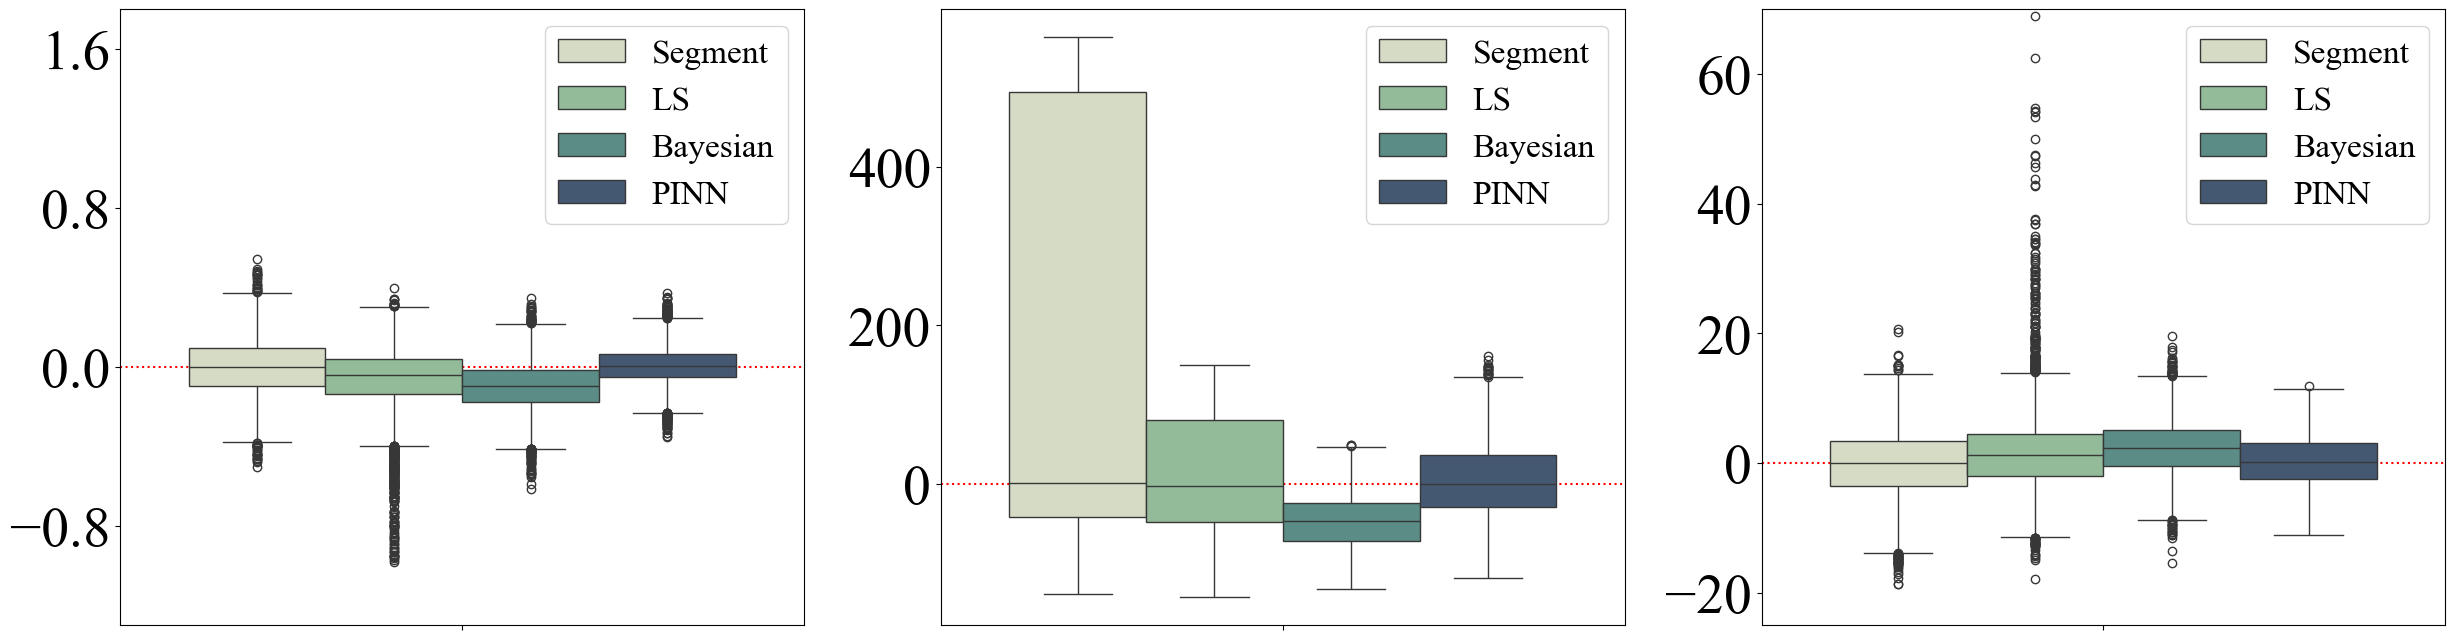

In [45]:
plt.rc('font',family='Times New Roman')
plt.figure(figsize=(30,8))
y_datas=['Dslow','Dfast','Ffast']
y_labels=['Dt','Dp','Fp']
palette = sns.color_palette('Blues',2)

plt.subplot(1,3,1)
plt.xticks(fontsize=40)
#plt.yticks(fontsize=40)
plt.ylim(-1.3, 1.8)
plt.yticks([-0.8,0,0.8,1.6],fontsize=40)
plt.axhline(y=0., color='r', linestyle=':')
sns.boxplot(hue="Strategy",y=y_datas[0],data=df,whis=1.5,showfliers=True, palette=sns.cubehelix_palette(5,start=.5,rot=-.75))

plt.xlabel('')
plt.ylabel('')
#plt.xlabel("Error",fontsize=40)
#plt.ylabel(y_labels[i], fontsize=40)
plt.legend(loc = 'upper right',fontsize=24)

plt.subplot(1,3,2)
plt.xticks(fontsize=40)
plt.yticks([-200,0,200,400,600],fontsize=40)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
sns.boxplot(hue="Strategy",y=y_datas[1],data=df,whis=1.5,showfliers=True, palette=sns.cubehelix_palette(5,start=.5,rot=-.75))

plt.xlabel('')
plt.ylabel('')
#plt.xlabel("Error",fontsize=40)
#plt.ylabel(y_labels[i], fontsize=40)
plt.legend(loc = 'upper right',fontsize=24)

plt.subplot(1,3,3)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.ylim(-25, 70.)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
sns.boxplot(hue="Strategy",y=y_datas[2],data=df,whis=1.5,showfliers=True, palette=sns.cubehelix_palette(5,start=.5,rot=-.75))

plt.xlabel('')
plt.ylabel('')
#plt.xlabel("Error",fontsize=40)
plt.yticks([-20,0,20,40,60],fontsize=40)
plt.legend(loc = 'upper right',fontsize=24)

plt.savefig(r'C:\Users\Administrator\Desktop\boxplot.jpg' , dpi = 1000)